In [138]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner
import h5py
import numpy.ma as ma
from scipy.interpolate import interp1d
import pickle 
import scipy.constants as const
from scipy import interpolate
from multiprocessing import Pool
import arviz as az
from datetime import datetime

## Sky Tmeas Data

In [139]:
with open('/home/saurabhs/Documents/gopi/avg_data_dict_2024-05-20_165119.pkl', 'rb') as f:

    file_loaded= pickle.load(f)
    
avg_masked_TMeas=file_loaded['avg_masked_data']  ## Averaged and Masked Real Data 
v_MHz=file_loaded['frequency_MHz']  ## Frequencies
raw_avg_TMeas=file_loaded['raw_avg']  ## Unmasked and Averaged Real Data
act_uncert=file_loaded['masked_error']  ## Masked Uncertainities

# plt.plot(v_MHz, avg_masked_TMeas,'.')
# plt.grid(color='grey', linestyle='-.', linewidth=0.5)
# plt.xlabel("Freq(MHz)")
# plt.ylabel("Temp(K)")
# plt.title("Averaged Measured Temp")

In [140]:
# plt.plot(avg_masked_TMeas, '.')


## Enhanced Flags

In [141]:
new_mask = np.loadtxt('/home/saurabhs/Documents/amarnath/saras/avg_data_dict_2024-05-20_165119_mask.txt')
new_mask = new_mask.astype(bool)
inv_mask = ~new_mask


In [142]:
masked_TMeas = np.ma.array(avg_masked_TMeas, mask= inv_mask)
#plt.plot(masked_TMeas, '.')
mask_ = ~np.isnan(masked_TMeas)#(avg_masked_TMeas)  ##consider the true values
masked_ind_ = np.where(new_mask)[0]


## Limiting Frequencies

In [146]:
freq_indices=[]
v_lim=[]
v_lim = [v for v in v_MHz if 45 < v < 110]
freq_indices = [i for i, v in enumerate(v_MHz) if 45 < v < 110]


In [144]:
# with open('/home/saurabhs/Documents/gopi/real_data_datewise.pkl', 'rb') as f:
#     real_data = pickle.load(f)
# scnd_night_Tmeas=real_data['2024-05-23']
# scnd_night_Tmeas_avg= np.mean(scnd_night_Tmeas, axis=0)
# print(scnd_night_Tmeas.shape)

In [102]:
# mask = ~np.isnan(scnd_night_Tmeas)
# scnd_night_Tmeas_clean=scnd_night_Tmeas[mask]
# scnd_night_Tmeas_avg_clean= np.mean(scnd_night_Tmeas_clean, axis=0)
# plt.plot(scnd_night_Tmeas_avg, '.')
# print(scnd_night_Tmeas_clean.shape)

## Limiting Data corres to limited frequencies

In [147]:
TMeas_lim= masked_TMeas[freq_indices]#avg_masked_TMeas[freq_indices]
act_uncert_lim= act_uncert[freq_indices]
print(len(TMeas_lim))

2130


### Removing NaN values

In [148]:
# Considering only non-Nan values
## alternate frequencies are masked
mask = ~np.isnan(TMeas_lim)#(avg_masked_TMeas)  ##consider the true values
masked_ind = np.where(mask)[0]

#Keep only non Nan entries
TMeas_clean = TMeas_lim[mask] #avg_masked_TMeas[mask]

act_uncert_clean = act_uncert_lim[mask] #act_uncert[mask]
v_lim = np.array(v_lim)
v_clean = v_lim[masked_ind]

# plt.plot(v_clean, TMeas_clean)
# plt.grid()
# plt.title('TMeas without Nans')

In [ ]:
### Plot
# plt.plot(v_clean, TMeas_clean)
# plt.title("TMeas without nan values")
# plt.grid(linestyle='-.')
# plt.xlabel('Freq (MHz)')
# plt.ylabel('Temp (K)')
# plt.show()

In [ ]:
# interpolator = interp1d(v_clean, TMeas_clean, kind='linear')
# freq_new = np.linspace(np.min(v_clean),np.max(v_clean), len(v_MHz))

# ##Interpolated RLC
# TMeas_new=interpolator(freq_new)
# plt.plot(v_MHz, TMeas_new)
# plt.title('Interpolated TMeas')
# plt.xlabel('Freq (MHz)')
# plt.ylabel('Temp (K)')
# plt.grid(linestyle='-.')

In [ ]:
# plt.plot(v_MHz,TMeas_new-avg_masked_TMeas,'.')

## GMOSS PSky Simulated without correcting for Tot Eff

In [149]:
#PSky_data = np.loadtxt("/home/saurabhs/Documents/gopi/simulated_data_2024-05-20_165119_GMOSS.txt")
with open('/home/saurabhs/Documents/gopi/simulated_data_datewise.pkl', 'rb') as f:
       data = pickle.load(f)
GMOSS_PSky_data = data['2024-05-20']
 

### Colormap

In [150]:
GMOSS_PSky_data=np.array(GMOSS_PSky_data)
time = np.arange(GMOSS_PSky_data.shape[0])    
LOWF= 70 #40
HGHF= 110
freq_subset = v_clean#np.linspace(LOWF, HGHF, PSky_data.shape[1]) 

### Plots
# plt.figure(figsize=(12,6))
# plt.pcolormesh(time, v_MHz, (GMOSS_PSky_data).T, shading="auto", cmap="viridis")

# plt.colorbar(label="Temp (K)")
# plt.xlabel("Time (Secs)")
# plt.ylabel("Frequency (MHz)")
# plt.title("Frequency vs Time Heatmap (40–110 MHz)")
# plt.show()

## Singular Value Decomposition of GMoss PSky Data

In [151]:
U, S, Vt = np.linalg.svd(GMOSS_PSky_data, full_matrices=False)
spectral_modes = Vt        # v_i(ν)
temporal_modes = U         # u_i(t)

In [152]:
K = 5  # number of spectral modes considered

U_K  = U[:, :K]          # (Nt × K)
S_K  = S[:K]             # (K,)
Vt_K = Vt[:K, :]         # (K × Nν)

GMOSS_PSky_recon = U_K @ np.diag(S_K) @ Vt_K


In [153]:
for nn in range(5):
    sum_spectral_modes=+ spectral_modes[nn]
# plt.plot(sum_spectral_modes)


In [154]:
GMOSS_PSky_data=np.array(GMOSS_PSky_recon)
time = np.arange(GMOSS_PSky_recon.shape[0])    
LOWF= 50
HGHF= 110
freq_subset = v_MHz#np.linspace(LOWF, HGHF, PSky_data.shape[1]) 

### Plots
# plt.figure(figsize=(12,6))
# plt.pcolormesh(time, v_MHz, (PSky_recon-PSky_data).T, shading="auto", cmap="viridis")

# plt.colorbar(label="Temp (K)")
# plt.xlabel("Time (Secs)")
# plt.ylabel("Frequency (MHz)")
# plt.title("Frequency vs Time Heatmap (40–110 MHz)")
# plt.show()

In [155]:
### Plots
# plt.figure()
# plt.plot(1+np.arange(len(S)),S/np.amax(S))
# plt.scatter(1+np.arange(len(S)),S/np.amax(S), color='b')
# plt.yscale('log')
# plt.xscale('log')
# plt.axhline(y=1e0, color='r', ls='--', lw=3.0)
# plt.axhline(y=1e-6, color='k', ls='--', lw=3.0)
# plt.grid()
# plt.show()

In [156]:
## Plots for different spectral modes
# plt.plot(v_MHz, -spectral_modes[0])
# plt.plot(v_MHz, -spectral_modes[1])
# plt.plot(v_MHz, -spectral_modes[2])
# plt.plot(v_MHz, -spectral_modes[3])
# plt.plot(v_MHz, -spectral_modes[4])
# plt.plot(v_MHz, -spectral_modes[5])
# plt.grid()

### Averaged Sky SVD Data

In [157]:
## Averaged Sky data
Avgd_GMOSS_PSky=np.mean(GMOSS_PSky_recon,axis=0)

## Frequency Limited Avg PSky
Avgd_GMOSS_PSky_lim= Avgd_GMOSS_PSky[freq_indices]

## Removing Nan Values
Avgd_GMOSS_PSky_clean = Avgd_GMOSS_PSky_lim[mask]


check = np.mean(GMOSS_PSky_data, axis=0)[freq_indices]
check_clean = check[mask]
### Plots 
# plt.plot(v_clean, Avgd_GMOSS_PSky_clean- check_clean)
# plt.title('Averaged PSky without mask frequencies')
# plt.xlabel("Freq(MHz)")
# plt.ylabel("Temp(K)")
# plt.grid(linestyle='-.')


### Fitting GMOSS Sky data

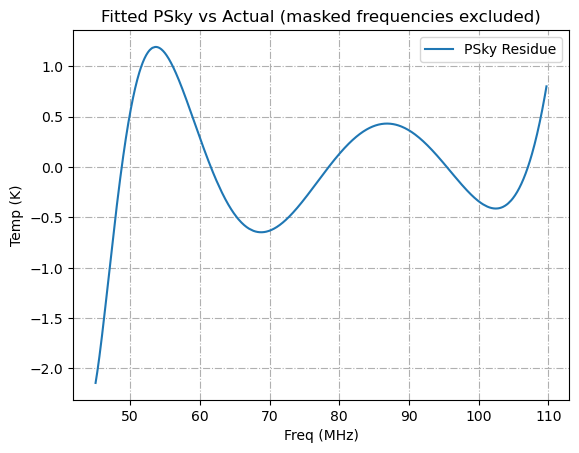

[  -8.68596247   77.34073208 -275.10479734  488.50041577 -435.33526482
  161.13661379]


In [158]:
cc_sky_log=np.polyfit(np.log10(v_MHz), np.log10(Avgd_GMOSS_PSky),5) ## Fitting on the log scale


sky_fit_log_clean = np.polyval(cc_sky_log,np.log10(v_clean))

sky_fit_K_clean= np.power(10.0, sky_fit_log_clean, dtype=np.float64) # Back from log scale

## Residuals
res_sky = sky_fit_K_clean-Avgd_GMOSS_PSky_clean
rms_sky=np.std(res_sky)

#print(cc_sky_log)
## Plots
# plt.plot(v_clean, sky_fit_K_clean, label='Fitted PSky')
# plt.plot(v_clean, Avgd_GMOSS_PSky_clean,'.', label='PSky', zorder=-1)
plt.plot(v_clean, res_sky, label='PSky Residue')
plt.grid(linestyle='-.')
plt.legend()
plt.title('Fitted PSky vs Actual (masked frequencies excluded)')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.show()
print(cc_sky_log)

#### Residuals

In [ ]:
# plt.plot(v_clean, res_sky, label='Residuals1')
# plt.text(0.5, 0.85, f"RMS = {rms_sky}", transform=plt.gca().transAxes,fontsize=10, color='red')

# plt.grid(linestyle='-.')
# plt.legend()
# plt.title('Residuals')
# plt.show()


### PSky Coeffs

In [159]:
GMOSS_PSky_coeffs= cc_sky_log
#[-8.50708779,   75.74694151, -269.42869695,  478.4010676,  -426.35767456, 157.94801389]#cc_sky_log

#print("PSky_coeffs:{}".format(PSky_coeffs))

## SKY S11 Data

In [160]:
data = map(lambda x: [ x[0], x[1] ], # Phase and Magnitude
        np.loadtxt("/home/saurabhs/Documents/gopi/andaman_deployment_S11_1.txt", skiprows=0))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=const.c  # speed of light (m/s)
freq=np.linspace(40, 110, 101)
#[d[i][0] for i in range(len(d))] #frequency
df=pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/S11_for_freq.csv')
#rlc = df[df.columns[1]].values.tolist()

gamma_Asky=[d[i][0] for i in range(len(freq))]
#freq_MHz=np.array(freq)#/1e6

# plt.plot(freq, gamma_Asky, label="Gamma for sky")
# plt.legend()
# plt.xlabel("Freq(MHz)")
# plt.ylabel("gamma_A")
# plt.grid(color='grey', linestyle='-.', linewidth=0.5)

### Interpolating the S11 for the required frequencies

In [161]:
interpolator = interp1d(freq, gamma_Asky, kind='linear')
freq_new = v_MHz #np.linspace(np.min(freq),np.max(freq), len(v_MHz))
freq_clean= v_clean

##Interpolated RLC
gamma_Asky_new_clean= interpolator(freq_clean)


# plt.plot(freq, gamma_Asky,'r',label="S11 data")
# plt.plot(v_clean, gamma_Asky_new_clean,'k--', zorder=2, linewidth=2, label="Interpolated S11")

# plt.grid(color='purple', linestyle='-.', linewidth=0.5)
# plt.legend()
# plt.xlabel("Freq (MHz)")
# plt.ylabel("gamma_A")
# plt.title("Gamma A (40-110MHz)")
# plt.show()

#### Residuals of the fit

In [162]:
cc=np.polyfit(v_clean, gamma_Asky_new_clean, 6)
#cc=np.polyfit(v_MHz, gamma_Asky_new, 6)
print('S11 Fit Coeffs:{}'.format(cc))
S11_fit = np.polyval(cc, v_clean)

## Residuals
res_S11 = S11_fit - gamma_Asky_new_clean
rms = np.std(res_S11)

# plt.plot(v_clean,res_S11)
# plt.text(0.5, 0.85, f"RMS = {rms}", transform=plt.gca().transAxes,fontsize=10, color='red')
# plt.title("S11 fit residuals")
# plt.grid(linestyle='-.')


S11 Fit Coeffs:[-1.13895327e-11  5.97696854e-09 -1.26795198e-06  1.39959611e-04
 -8.34396424e-03  2.37785402e-01 -1.64127297e+00]


In [163]:
S11_Sky_coeffs= [-1.13895327,  5.97696854, -1.26795198,  1.39959611, \
                 -8.34396424,  2.37785402, -1.64127297]

#[-1.39805476,  7.23704267, -1.52020783, 1.66552801, -9.90020758,  2.85696175, -2.24725213]
#[1.84757821, -5.73960918,  6.35752753, -2.39187703, -4.65531407,  3.73416720,  4.66178790]
#[-8.42206054,  4.57072534, -9.94498267,  1.12055732, 6.76947624,  1.91244810, -1.07862193]



# Total Efficiency

## GMOSS Total Efficiency

In [ ]:
# Tot_eff_coeffs=np.loadtxt("/home/saurabhs/Documents/gopi/total_efficiency_coefficients.txt")
# Tot_eff= np.polyval(Tot_eff_coeffs,v_MHz) 

# Tot_eff_clean= np.polyval(Tot_eff_coeffs,v_clean)

# plt.plot(v_clean,Tot_eff_clean)
# plt.title('Total Efficiency')
# plt.grid(linestyle='-.')
# print(len(Tot_eff_coeffs))

[ 4.71779028e-12 -2.59925698e-09  5.98996459e-07 -7.45985742e-05
  5.40347713e-03 -2.27094336e-01  5.13508960e+00 -4.83340411e+01]


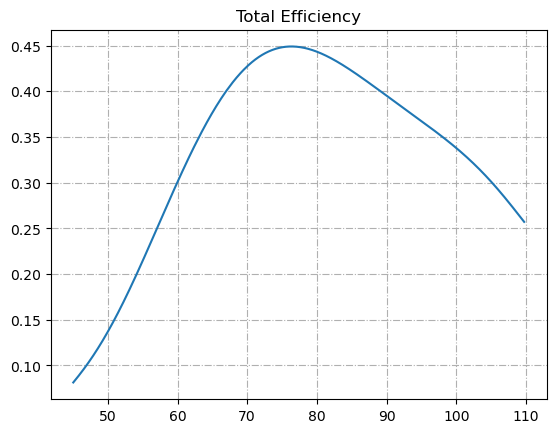

In [164]:
with open('/home/saurabhs/Documents/gopi/coefficient_tot_eff.pkl', 'rb') as f:

    tot_eff_file= pickle.load(f)
Tot_eff_cc= tot_eff_file['2024-05-20']
Tot_eff_clean= np.polyval(Tot_eff_cc, v_clean)
#Tot_eff = np.polyval(Tot_eff_cc, v_MHz)
#TE_lim= np.polyval(Tot_eff_cc, v_clean)
plt.plot(v_clean,Tot_eff_clean)
plt.title('Total Efficiency')
plt.grid(linestyle='-.')
print((Tot_eff_cc))

## GMOSS Tot Eff coeff

In [165]:
GMOSS_Tot_eff_coeffs= [4.71779028, -2.59925698,  5.98996459, -7.45985742,\
                 5.40347713, -2.27094336,  5.13508960, -4.83340411]
#[5.29402336, -2.82620291,  6.29254661, -7.54286418, 5.23292304, -2.09326760,  4.47190674, -3.94045734]

## Tot Eff from FICCO Sim

In [ ]:
Tot_eff_file_path="/home/saurabhs/Documents/gopi/tot_eff_155mm.dat"
Tot_eff_data = np.loadtxt("/home/saurabhs/Documents/gopi/tot_eff_155mm.dat", skiprows=2)
Tot_eff_freq =Tot_eff_data[:,0]/1e6 ## In MHz
ficco_tot_eff_data = Tot_eff_data[:,1]
plt.plot(Tot_eff_freq,ficco_tot_eff_data)
plt.grid()
plt.title('FICCO Simulated Tot Eff')
print(len(ficco_tot_eff_data))

In [ ]:
interpolator = interp1d(Tot_eff_freq, ficco_tot_eff_data, kind='linear')
freq_new = v_clean #np.linspace(np.min(freq),np.max(freq), len(v_MHz))

##Interpolated RLC
ficco_tot_eff = interpolator(freq_new) 
#ficco_tot_eff_clean =ficco_tot_eff[mask]
plt.plot(Tot_eff_freq, ficco_tot_eff_data,'r',label="Tot Eff data")
plt.plot(v_clean, ficco_tot_eff,'k--', zorder=2, linewidth=2, label="Interpolated Tot Eff")

plt.grid(color='purple', linestyle='-.', linewidth=0.5)
plt.legend()
plt.xlabel("Freq (MHz)")
#plt.ylabel("gamma_A")
#plt.title("Gamma A (40-110MHz)")
plt.show()

In [ ]:
## FICCO Tot Eff Coeffs
ficco_tot_eff_cc=np.polyfit(v_MHz, ficco_tot_eff, 7)
ficco_tot_eff_fit = np.polyval(ficco_tot_eff_cc, v_MHz)

## Residuals

res_tot_eff = ficco_tot_eff_fit - ficco_tot_eff
rms_tot_eff = np.std(res_tot_eff)

plt.plot(v_MHz,res_tot_eff)
plt.text(0.5, 0.85, f"RMS = {rms_tot_eff}", transform=plt.gca().transAxes,fontsize=10, color='red')
plt.title("Ficco Tot Eff fit residuals")
plt.grid(linestyle='-.')
print('Ficco Tot Eff coeffs: {}'.format(ficco_tot_eff_cc))

In [ ]:
ficco_tot_eff_coeffs=[1.12183080, -4.49528730,  6.10158906, -1.78290634,\
                      -3.37182546,  3.47616727, -1.13600375,  1.28726131]

## 21cm signal

In [166]:
path_to_file = '/home/saurabhs/Documents/gopi/Saras_New/Data_18March_wMFP.mat'
path_to_freq = '/home/saurabhs/Documents/gopi/Saras_New/freq_saras.txt'

data     = scipy.io.loadmat(path_to_file)
data     = data['Data2']/1e3  # Kelvin units

fr       = np.loadtxt(path_to_freq) #Frequency in MHz
signal_function   = interpolate.interp1d(fr, data, fill_value="extrapolate")

In [167]:
F_MIN = 45 # define your own

F_MAX = 110 # define your own

NO_OF_CHANNELS = len(v_clean) # define your own

freq_array = np.linspace(F_MIN, F_MAX, NO_OF_CHANNELS) 

signals = signal_function(freq_array)


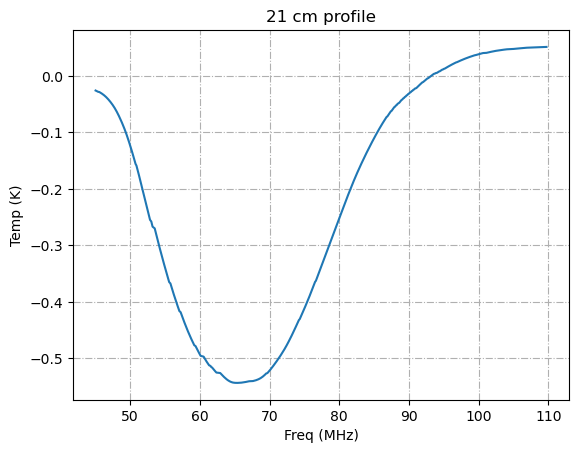

In [168]:
sig_idx = 63
sig21cm=3*signals[sig_idx]

plt.plot(v_clean, sig21cm)
plt.title('21 cm profile')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.grid(linestyle='-.')
plt.show()


## Saving input values

In [173]:
#Saving input values in a pickel file
# Ask user for confirmation
now = datetime.now()
date_string = now.strftime("%Y-%m-%d")

PSky = Avgd_GMOSS_PSky_clean
PSky_coeffs = GMOSS_PSky_coeffs 
S11_params = S11_Sky_coeffs 
Tot_eff_coeffs = GMOSS_Tot_eff_coeffs  
PW_t = 297
PN_t = 70 
gN_t=0.13
f_t=0.1
l_t=0.15
phi_t=0

#confirm = input("Do you want to save the pickle file? (y/n): ").strip().lower()
confirm="y"
if confirm == "y":
    result={"PSky":PSky,"PSky_coeffs":PSky_coeffs,"S11_params":S11_params,"Tot_eff_coeffs":Tot_eff_coeffs,"PW_t":PW_t,"PN_t":PN_t, "gN_t": gN_t, \
            "f_t":f_t, "l_t":l_t, "phi_t":phi_t, "req_freq":v_clean, "Real Data":TMeas_clean, "act_uncert":act_uncert_clean, "sig21cm": sig21cm}

    with open(f"{date_string}_inp_values_sky_andmndata_GMOSS_45-110.pkl", 'wb') as file:  # open a text file
        pickle.dump(result, file) # serialize the list

    file.close()
else:
     print("Save cancelled.")

### Reading Open Run Data

In [ ]:
with open('2025-10-31_results_Opn_38_realdata.pkl_L_10_70', 'rb') as f:

    result_loaded= pickle.load(f) # deserialize using load()
#seed=result_loaded["seed"]
#req_freq=result_loaded["req_freq"]#----------------- Frequencies
samples_o=result_loaded["samples"]#------------------- Flattened samples after burn
full_samples_o=result_loaded["full_samples"]#--------- All samples
best_fit_o=result_loaded["best_fit"]#----------------- Max likelihood values
parameter_names_o=result_loaded["param_names"]#------- Param names
true_params_o=result_loaded["true_params"]#----------- Actual Parameter values
Tmeas_Actual_o=result_loaded["Real Data"]#------------ Actual TMeas

## Reading S11 free run data

In [ ]:
with open('2025-11-25_results_sky_1_a1s1_andmndata_S11_Free.pkl', 'rb') as f:

    result_loaded= pickle.load(f) # deserialize using load()
#seed=result_loaded["seed"]
#req_freq=result_loaded["req_freq"]#----------------- Frequencies
samples_free=result_loaded["samples"]#------------------- Flattened samples after burn
full_samples_free=result_loaded["full_samples"]#--------- All samples
best_fit_free=result_loaded["best_fit"]#----------------- Max likelihood values
parameter_names_free=result_loaded["param_names"]#------- Param names
true_params_free=result_loaded["true_params"]#----------- Actual Parameter values
Tmeas_Actual_free=result_loaded["Real Data"]#------------ Actual TMeas
S11_params_free=result_loaded["S11_params"]
peak_params_free=result_loaded["peak_params"]

In [ ]:
parameter_names_free[13:23]

In [ ]:
PSky_coeffs_free = best_fit_free[:6] #best_fit_free[:6]
S11_Sky_coeffs_free = best_fit_free[6:13] #best_fit_free[6:13]
Tot_eff_coeffs_free = best_fit_free[13:23]#best_fit_free[13:23]

In [ ]:
t0,t1,t2,t3,t4,t5,t6,t7,t8,t9=Tot_eff_coeffs_free
Tot_eff_free= np.polyval([t0*1e-15, t1*1e-12, t2*1e-9, t3*1e-7, t4*1e-5, t5*1e-3,\
                        t6*1e-2, t7, t8*1e+1, t9*1e+2],v_clean)
plt.plot(v_clean, Tot_eff_free, label="Best")
plt.plot(v_clean, Tot_eff_clean, label="Actual")
plt.title('Tot Eff Actual vs Best')
plt.legend()
plt.grid(linestyle='-.')

## Seed

### Tot eff and S11 fixed run

In [ ]:
# ########### Define the log-likelihood function
# def log_likelihood_fixed(params, seed, v, s, weights, TA_exp, S11_params, Tot_eff_coeffs):

#     np.random.seed(seed)
    
#     # Compute model TA

#     P0,P1,P2,P3,P4,P5, PW, PN, gamma_N, f,l, phi = params
#     PA_coeffs = P0,P1,P2,P3,P4,P5
#     Tot_eff_coeffs = Tot_eff_coeffs
#     S11_params = S11_params
#     TA_model = Compute_Tmeas_Sky(PA_coeffs, S11_params, Tot_eff_coeffs, \
#                                  PW, PN, gamma_N, f, l, phi, v)

#     TA_model=np.array(TA_model)#+a*signal#+b*s

#     # Compute chi-squared
#     chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 
#     #chi2 = np.sum([((TA_exp - TA_model)** 2)*weights ]) 

#     return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)

# ########## Define the log-prior function
# def log_prior_fixed(params, v, debug):

#     P0,P1,P2,P3,P4,P5, PW, PN, gamma_N, f, l, phi = params
#     v=v
    
#     PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(v))
#     with np.errstate(over='ignore'):
#         PA= np.power(10.0, PSky_log, dtype=np.float64)
    
# #     t0,t1,t2,t3,t4,t5,t6,t7,t8,t9 = Tot_eff_coeffs 
# #     Tot_eff= np.polyval([t0*1e-15, t1*1e-12, t2*1e-9, t3*1e-7, t4*1e-5, t5*1e-3,\
# #                         t6*1e-2, t7, t8*1e+1, t9*1e+2],v) 
#     #if (a>0 and 0<=gamma_N<=1 and np.amin(PSky_log)>0 and np.amax(PSky_log)<300 and Pref>0 and PN>0 and f>0 and 0.10<l<0.70): #np.amin(gamma_A)>=0 and np.amax(gamma_A)<=1 and ):
#         #return 0.0  # Accept sample
    
#     #return -np.inf # Reject prior

#     ### Debugging:
#     if not np.all(PA > 0):
#         if debug: print(f"Prior failed: PA = {PA} not >0")
#         return -np.inf
# #     if not (np.amin(Tot_eff)>=0 and np.amax(Tot_eff)<=1):
# #         if debug: print(f"Prior failed: Tot_eff = {Tot_eff} not >0")
# #         return -np.inf
#     if not (299<PW<1000):
#         if debug: print(f"Prior failed: PW = {PW} not >0")
#     if not (PN>0):
#         if debug: print(f"Prior failed: PN = {PN} not >0")
#         return -np.inf
#     if not (0 <= gamma_N <= 1):
#         if debug: print(f"Prior failed: gamma_N = {gamma_N} not in [0,1]")
#         return -np.inf
#     if not (0<f<=1):
#         if debug: print(f"Prior failed: f = {f} <= 0")
#         return -np.inf
#     if not (0.10 < l < 1.00):  # fixed the logic — your original had it reversed
#         if debug: print(f"Prior failed: l = {l} not in (0.10, 0.70)")
#         return -np.inf

#     return 0.0

    
# ######### Define the full log-probability function
    
# def log_probability_fixed(params, seed, v, s, weights, TA_exp, S11_params, Tot_eff_coeffs, debug):
#     lp = log_prior_fixed(params, v, debug)
    
#     if not np.isfinite(lp):
#         return -np.inf
#     return lp + log_likelihood_fixed(params, seed, v, s, weights, TA_exp, S11_params, Tot_eff_coeffs)


# ########## MCMC for RLC Coeffs.
# def evolve_MCMC_Fixed(**kwargs):

#     #debug=True
#     ## Number of walkers and steps
#     ndim = 12  # Number of parameters
#     nwalkers = 150  # Number of MCMC walkers
#     nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
#     ## Initialize walkers around a random point in parameter space
    
#     initial_value=kwargs["initials"]
#     seed=kwargs["seed"]
#     v=kwargs["v"]
#     s=kwargs["s"]
#     weights=kwargs["weights"]
#     TA_exp=kwargs["TA_exp"]
#     S11_params = kwargs["Sky_S11_params"]
#     Tot_eff_coeffs=kwargs["Tot_eff_coeffs"]
#     signal=kwargs["signal"]
#     debug=kwargs["debug"]

#     #PA_cc=kwargs["PA_Coeffs"]

#     ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
#     np.random.seed(seed+1)
    
#     pos_valid = []
#     while len(pos_valid) < nwalkers:
#         trial =np.array(initial_value) + 1e-3 * np.random.normal(size=ndim)# initial_value + 1e-1 * np.random.randn(ndim)
        
#         if np.isfinite(log_prior_fixed(trial ,v, debug)):
#             pos_valid.append(trial)
#     pos = np.array(pos_valid)
    
#     #pos = np.array(initial_value)[None,:] + 1e-1*np.random.normal(0,1,size=(nwalkers,ndim))

#     ## for making sure only positive positional values
#     """
#     for idim in range(ndim):
#         ind_pos = pos[:,idim]<0
#         pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
#     """ 
#     ## Set up the MCMC sampler
#     with Pool() as pool:
#         sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_fixed,\
#                                         args=(seed, v, s, weights, TA_exp, S11_params,Tot_eff_coeffs, debug), pool=pool)

#         ## Run MCMC

#         print("Running MCMC...")
#         sampler.run_mcmc(pos, nsteps, progress=True)
    
#     ## Extract the samples
#     burn=4500
#     full_samples=sampler.get_chain()
#     samples = sampler.get_chain(discard=burn, flat=True)
#     #tau = sampler.get_autocorr_time(discard=burn, tol=0, quiet=True)
#     ## Acceptance Fraction
#     af_per_walker = sampler.acceptance_fraction      # array shaped (nwalkers,)
#     af_mean = af_per_walker.mean()
#     #print("tau (best-effort):", tau)
#     #print("tau_max:", np.max(tau))
    
#     return full_samples,samples, pos, af_per_walker, af_mean#, tau

### Intialising for MCMC for Tot Eff and S11 Fixed Run

In [ ]:
# #evolve MCMC fixed with initials for system parameters from Open

# seed=seed_main+2
# P0,P1,P2,P3,P4,P5 = PSky_coeffs #PSky_coeffs 
 
# a=1 ## multiplication factor for the signal
# PAo, gAo, PNo, gNo, fo, lo, phio= best_fit_o ## In case initials are taken from best fit of the open run
# #PWf, PNf, gNf, ff, lf, phif = peak_params_free[23:]
# initials =[P0,P1,P2,P3,P4,P5, PW_t, PN_t, gN_t, f_t, l_t, phi_t]  ##initials for mcmc walkers

# nsteps=5000
# signal= sig21cm ## 21cm signal
# debug=False
# s=act_uncert_clean ## uncertainity
# weights= 0

# kwargs = {"s":s, "weights":weights, "v":v_clean, "seed":seed, "nsteps":nsteps, "initials":initials, \
#           "TA_exp":TMeas_exp, "Sky_S11_params":S11_Sky_coeffs_clean, "signal":signal, "Tot_eff_coeffs":Tot_eff_coeffs, "debug":debug} #"ip_params":ip_params}




#### Checking Initials

In [ ]:
# print("Initial value check:", log_prior_fixed(np.array(initials), v_clean, debug=True))

#### MCMC Run when Tot Eff and S11 Coeffs are Fixed

In [ ]:
# fixed_samples_full, fixed_samples, fixed_initial_pos, fixed_af_per_walker, fixed_af_mean= evolve_MCMC_Fixed(**kwargs)

#### Computing Max Log Likelihood and Best Fit Params for Fixed run

In [ ]:
#  ## Compute log-likelihoods for all samples of fixed run
# log_likes_fixed = np.array([log_likelihood_fixed(p,seed,v_clean,s,weights,TMeas_exp,S11_Sky_coeffs_clean, Tot_eff_coeffs) for p in samples_fixed])

# ## Find the index of the maximum likelihood

# max_likelihood_index = np.argmax(log_likes_fixed)

# ## Get the best-fit parameters

# best_fit_params_fixed = samples_fixed[max_likelihood_index].tolist()

## Results

In [ ]:

# for i in range(0,len(params)):
#     P0, P1, P2, P3, P4, P5, t0,t1,t2,t3,t4,t5,t6,t7,\
#     PW, PN, gN, f, l, phi=params[i]

#     #P0, P1, P2, P3, P4, P5, PW, PN, gN, f, l, phi=params[i]
#     PSky_cc_p=[P0,P1,P2,P3,P4,P5]
#     Tot_eff_coeff_p=[t0,t1,t2,t3,t4,t5,t6,t7]

#     TMeas_=Compute_Tmeas_Sky(PSky_cc_p, S11_params, Tot_eff_coeff_p,\
#                              PW, PN, gN, f, l, phi, v_clean)#+a*sig21cm
#     plt.plot(v_clean,TMeas_)
    
# plt.plot(v_clean,TMeas_exp, 'o',label="Expected", zorder=-1)
# plt.title('Expected vs Obtained TMeas')
# plt.xlabel('Freq (MHz)')
# plt.ylabel('Temp (K)')
# plt.legend()
# plt.grid()


In [ ]:
# P0, P1, P2, P3, P4, P5, t0,t1,t2,t3,t4,t5,t6,t7, PW, PN, gN, f, l, phi = y_max

# PSky_cc_peak=[P0,P1,P2,P3,P4,P5]
# Tot_eff_coeffs_peak=[t0,t1,t2,t3,t4,t5,t6,t7]

# TMeas_peak=Compute_Tmeas_Sky(PSky_cc_peak, S11_params, Tot_eff_coeffs_peak,\
#                              PW, PN, gN, f, l, phi, v_clean)
    
# plt.plot(v_clean,TMeas_peak, label="Obtained with peak params")
# #plt.plot(v_clean,TMeas_exp, label="Expected")
# plt.title('TMeas Expected vs Obtained with peak params')
# plt.xlabel('Freq (MHz)')
# plt.ylabel('Temp (K)')
# plt.legend()
# plt.grid()
